# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("Số dòng: ",df.shape[0],"Số cột: ", df.shape[1])
print("Danh sách tên cột: ",", ".join(df.columns.tolist()))
print(df.info())

Số dòng:  541909 Số cột:  8
Danh sách tên cột:  InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB
None


## A.2. Missing values & Duplicate data

In [ ]:
# TODO
missing = df.isnull().sum()
print("Missing value: ")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu")
print()
duplicated = df.duplicated().sum()
print("Duplicate data: ", duplicated)
df[df.duplicated(keep=False)] 
print("Nhận xét: tuy có trùng lắp những đó chủ yếu là trùng InvoiceNo(Số hóa đơn) và CustomerID(mã KH) đó không phải lỗi mà là do có nhiều sản phẩm trong 1 hóa đơn")

Missing value: 
Description      1454
CustomerID     135080
dtype: int64

Duplicate data:  5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


## A.3. Invalid values

In [19]:
# TODO
print("StockCode is null: ", df['StockCode'].isnull().sum())
print("Quantity <= 0: ",(df['Quantity']<0).sum())
print("InvoiceDate is null: ",df['InvoiceDate'].isnull().sum())
print("UnitPrice <= 0: ",(df['UnitPrice']<0).sum())
print("CustomerID is null: ",df['CustomerID'].isnull().sum());
print(df['Country'].value_counts())
df


StockCode is null:  0
Quantity <= 0:  0
InvoiceDate is null:  0
UnitPrice <= 0:  0
CustomerID is null:  132220
Country
United Kingdom          485123
Germany                   9040
France                    8407
EIRE                      7890
Spain                     2484
Netherlands               2359
Belgium                   2031
Switzerland               1966
Portugal                  1501
Australia                 1182
Norway                    1071
Italy                      758
Channel Islands            748
Finland                    685
Cyprus                     614
Sweden                     451
Unspecified                446
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     295
Hong Kong                  284
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta        

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [18]:
# TODO
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['Sales'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [21]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"---{col}---")
    print(f"Mean= {mean_}, Median= {median_}, Mode= {mode_}")

---UnitPrice---
Mean= 3.9076252471213193, Median= 2.08, Mode= 1.25
---Quantity---
Mean= 10.542037034242338, Median= 3.0, Mode= 1
---Sales---
Mean= 20.121871451639677, Median= 9.9, Mode= 15.0


## Group 2 — Dispersion

In [23]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df[col]
    range_ = s.max() - s.min()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3-q1
    std_ = s.std()
    cv = std_/s.mean()*100
    print(f"---{col}---")
    print(f"range= {range_}, iqr= {iqr}, std= {std_}, cv= {cv}")

---UnitPrice---
range= 13541.329, iqr= 2.88, std= 35.915681104255434, cv= 919.1178486400123
---Quantity---
range= 80994, iqr= 9.0, std= 155.52412351063626, cv= 1475.2758219826712
---Sales---
range= 168469.59900000002, iqr= 13.950000000000003, std= 270.35674321840673, cv= 1343.596413823507


## Group 3 — Location and Shape

---UnitPrice---
Skew= 206.08697179737123, Kurtosis= 62482.55335737786
---Quantity---
Skew= 471.72638151377913, Kurtosis= 236460.11248175093
---Sales---
Skew= 506.70457814887453, Kurtosis= 297648.853558276


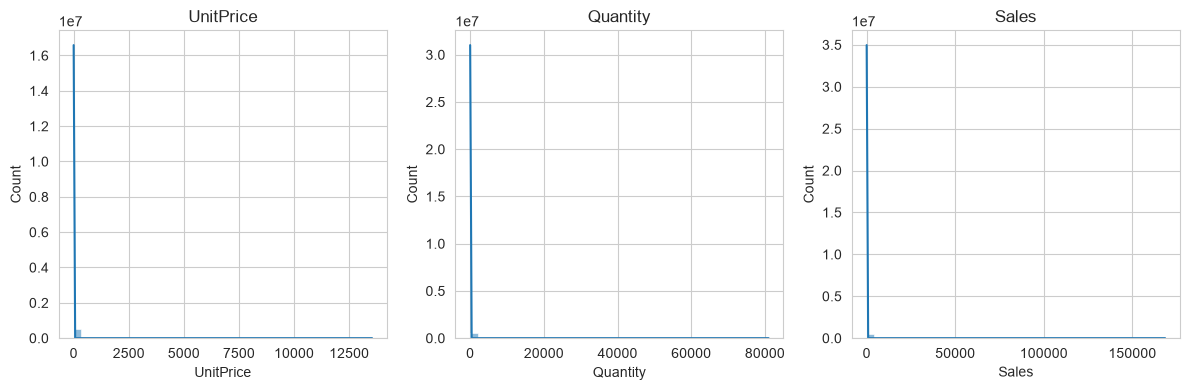

In [ ]:
# TODO
for col in ['UnitPrice', 'Quantity', 'Sales']:
    s = df[col]
    skew_, kurtosis_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"Skew= {skew_}, Kurtosis= {kurtosis_}")


fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.histplot(df['UnitPrice'], bins=40, kde=True, ax=axes[0]); axes[0].set_title('UnitPrice')
sns.histplot(df['Quantity'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('Quantity')
sns.histplot(df['Sales'], bins=40, kde=True, ax=axes[2]); axes[2].set_title('Sales')
plt.tight_layout(); plt.show()

print("Nhận xét: cả ba đồ thị đều có skew dương rất lớn -> đồ thì lệch phải rất mạnh. kurtosis cũng rất cao, đồng thời phần đuôi kéo dài cho thấy sự tồn tại của các giá trị ngoại lệ cực đoan")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [37]:
# TODO
dt = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print("Quốc gia có doanh thu cao nhất: ",dt.idxmax(),"| Doanh thu = ",dt.max().round(2))
tongDT = df['Sales'].sum()
ty_le = (dt.max()/ tongDT *100).round(2)
print(f"Chiếm {ty_le}% tổng doanh thu")

Quốc gia có doanh thu cao nhất:  United Kingdom | Doanh thu =  9025222.08
Chiếm 84.61% tổng doanh thu


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [39]:
# TODO
sp = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print(f"Sản phẩm bán chạy nhất theo doanh thu là {sp.idxmax()} với doanh thu = {sp.max()}")

Sản phẩm bán chạy nhất theo doanh thu là DOTCOM POSTAGE với doanh thu = 206248.77


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

In [41]:
# TODO
df['Month'] = df['InvoiceDate'].dt.month

print(df.groupby('Month')["Sales"].sum())
print("Nhận xét: Doanh số có tính mùa vụ. Từ tháng 9-12 doanh số tăng đáng kể. Tháng 11 có doanh số cao nhất. Từ tháng 1-8 có doanh số thấp hơn")

Month
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12    1462538.820
Name: Sales, dtype: float64
Nhận xét: Doanh số có tính mùa vụ. Từ tháng 9-12 doanh số tăng đáng kể. Tháng 11 có doanh số cao nhất. Từ tháng 1-8 có doanh số thấp hơn


## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [ ]:
# TODO
gtdh = df.groupby('Country')['Sales'].mean().sort_values(ascending=False)
print(gtdh)
print("Nhận xét: Giá trị đơn hàng trung bình có sự khác nhau giữa các quốc gia. Trong đó các nước 3 nước NetherLands, Australia, Japan có giá trị đơn hàng cao nhất")

Country
Netherlands             121.003111
Australia               117.192310
Japan                   116.561900
Singapore                95.852658
Sweden                   85.096075
Hong Kong                55.252817
Denmark                  49.882474
Lithuania                47.458857
Bahrain                  41.896667
Lebanon                  37.641778
EIRE                     35.925724
Brazil                   35.737500
Norway                   33.767918
Czech Republic           33.069600
Finland                  32.913985
Greece                   32.831172
Switzerland              29.038606
United Arab Emirates     27.974706
Israel                   27.577153
Channel Islands          27.340160
Austria                  25.624824
Germany                  25.317162
France                   24.945297
Spain                    24.789497
Malta                    24.335625
Canada                   24.280662
Iceland                  23.681319
Italy                    23.064960
Portugal    

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [ ]:
# TODO
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df2 = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])
print('Loaded from:', csv_path)

print("--------------------")
df2['Don_Hang_Huy'] = df2['Quantity']<0
tlgd = df2.groupby('Country')['Don_Hang_Huy'].mean()*100

print(tlgd.sort_values(ascending=False))
print("Nhận xét: USA có tỷ lệ trả hàng/hủy lớn nhất trong các quốc gia.")
print("Ngoài ra còn có các quốc gia có tỷ lệ trả hàng/hủy là 0%")

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv
--------------------
Country
USA                     38.487973
Czech Republic          16.666667
Malta                   11.811024
Japan                   10.335196
Saudi Arabia            10.000000
Australia                5.877681
Italy                    5.603985
Bahrain                  5.263158
Germany                  4.770932
EIRE                     3.684724
Poland                   3.225806
Singapore                3.056769
Sweden                   2.380952
Denmark                  2.313625
Spain                    1.894986
United Kingdom           1.855178
Belgium                  1.836636
Switzerland              1.748252
France                   1.741264
European Community       1.639344
Finland                  1.438849
Hong Kong                1.388889
Channel Islands          1.319261
Norway                   1.289134
Cyprus          

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Dữ liệu có nhiều dòng bị trùng và thiếu dữ liệu

UnitPrice có giá trị lớn và nhỏ nhất cách nhau 13541 đơn vị, giá trung bình là 3.9, dữ liệu biến động rất lớn 919%. Skew = 206 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

Quantity có giá trị lớn và nhỏ nhất cách nhau 80994 đơn vị, số lượng trung bình là 3.0, dữ liệu biến động rất lớn 1475%. Skew = 471 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

Quantity có giá trị lớn và nhỏ nhất cách nhau 80994 đơn vị, số lượng trung bình là 3.0, dữ liệu biến động rất lớn 270%. Skew = 506 -> đồ thị lệch phải rất nhiều cộng thêm kurtosis cao nên có khả năng xuất hiện giá trị cực đoan gây ảnh hưởng đến thống kê.

Giá trị đơn hàng trung bình có sự khác nhau giữa các quốc gia. Trong đó các nước 3 nước NetherLands, Australia, Japan có giá trị đơn hàng cao nhất

United Kingdom có doanh thu cao nhất với 9,025,222.084, chiếm 84.61% tổng doanh thu.

Doanh số có tính mùa vụ. Từ tháng 9-12 doanh số tăng đáng kể. Tháng 11 có doanh số cao nhất. Từ tháng 1-8 có doanh số thấp hơn

Sản phẩm có doanh thu cao nhất là DOTCOM POSTAGE với doanh thu 206,248.77 , cho thấy đây là sản đóng góp doanh thu lớn nhất.

Tỉ lệ hủy/trả hàng ở USA cao hơn nhiều so với tỉ lệ trả hàng ở các khu vực khác. Trong khi đó có nhiều quốc gia có tỉ lệ hủy/trả hàng là 0%